# 📌 Shap

### Interpreting models is an important part of machine learning, especially when dealing with black-box models like XGBoost or deep neural networks. SHAP (SHapley Additive exPlanations) provides a robust and sound method to interpret model predictions by making attributes of importance scores to input features.

## What is SHAP?
### SHAP is a method that helps us understand how a machine learning model makes decisions. It tells us how much each input (feature) is helping or hurting the final prediction. The main idea is to fairly distribute the "payout" (the prediction) among all features based on their contribution.

## Key Characteristics
- Model-Agnostic: Works with any machine learning model.
- Fair Attribution: Ensures consistent and fair distribution of feature importance.
- Additive Feature Attribution: Sum of SHAP values equals the model prediction minus the baseline.

Unlike traditional feature importance techniques, SHAP provides local explanations (per prediction) in addition to global feature importance, making it more versatile.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb

file_path = r"Data\SHAP_ex.txt"
columns = ["Sex", "Length", "Diameter", "Height", "WholeWeight", "ShuckedWeight", "VisceraWeight", "ShellWeight", "Rings"]

# Read the data
abalone = pd.read_csv(file_path, header=None, names=columns)

# One-hot encode 'Sex' and separate features
X = pd.get_dummies(abalone.drop("Rings", axis=1), columns=["Sex"], drop_first=True)
y = abalone["Rings"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [2]:
# Train the model
model = xgb.XGBRegressor()
model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [3]:
import shap
import warnings
warnings.filterwarnings('ignore')

# Explain the shap
explainer = shap.Explainer(model)
shap_values = explainer(X_test)
shap.initjs()

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Waterfall Chart

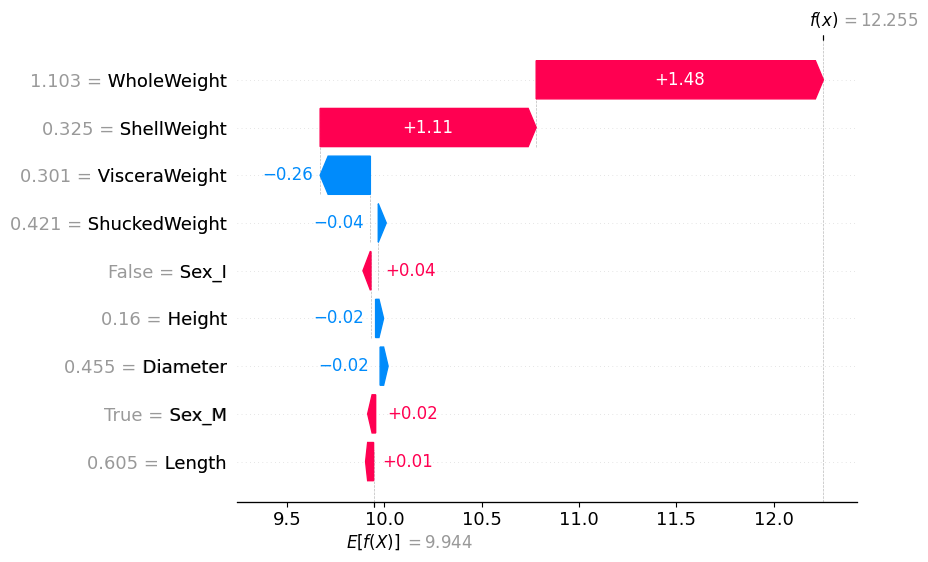

In [4]:
shap.waterfall_plot(shap_values[0])

# Force Chart

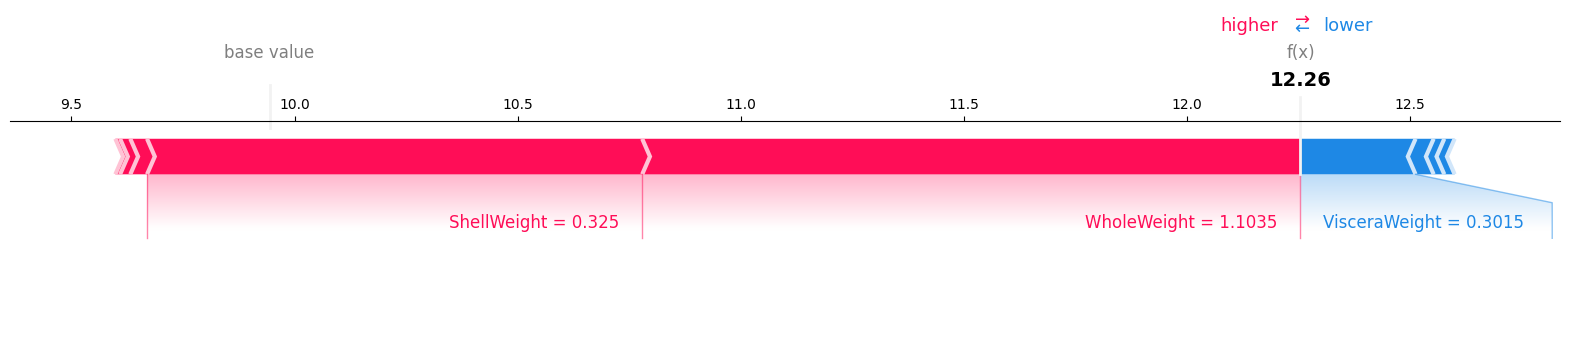

In [5]:
shap.force_plot(explainer.expected_value, shap_values[0].values, X_test.iloc[0, :], matplotlib=True)

# Summary Chart

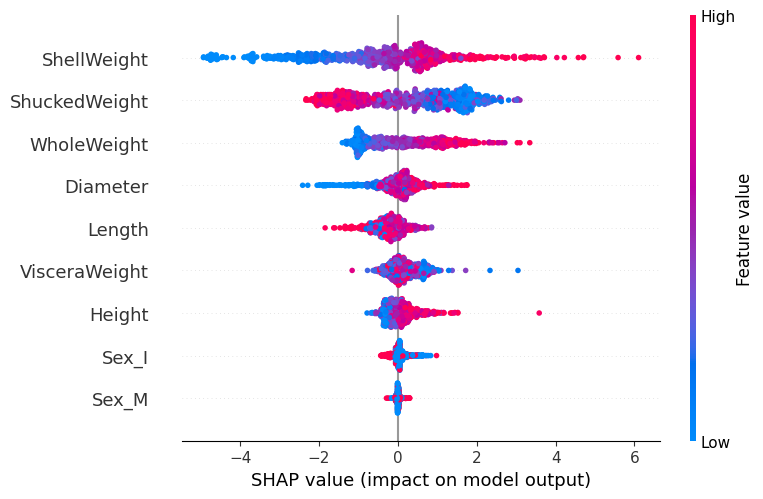

In [6]:
shap.summary_plot(shap_values, X_test)

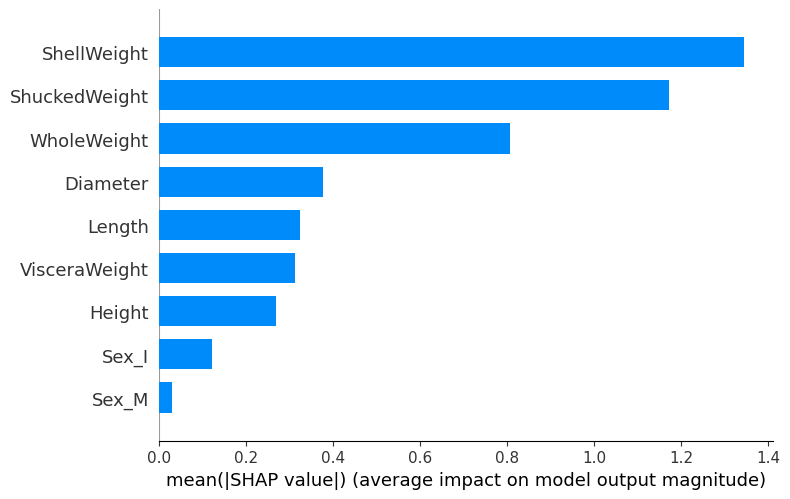

In [7]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

# Dependence Chart

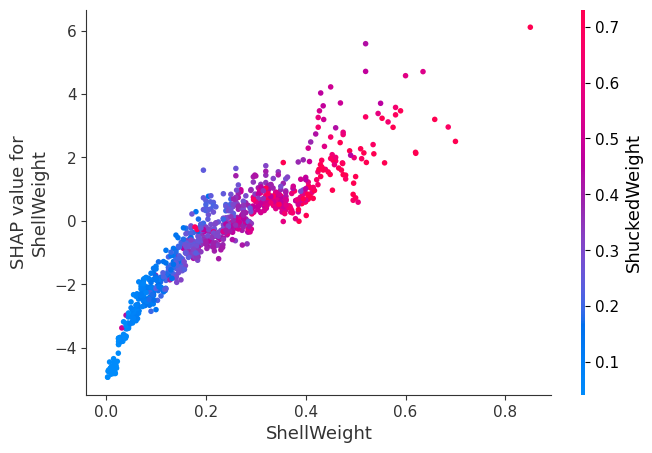

In [8]:
shap.dependence_plot("ShellWeight", shap_values.values,  X_test)

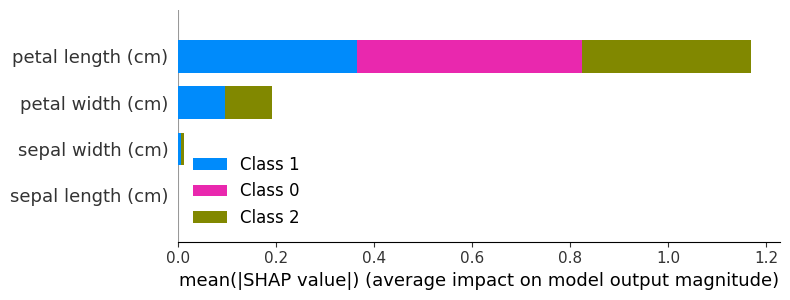

In [9]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

explainer = shap.Explainer(clf)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)